Testing implementations of modified Mid-measure

In [1]:
import numpy as np
import itertools
import functools as ft

In [ ]:


def mid_measurement(psi0: np.ndarray,
                qubit_list=None, cbit_list=None) -> tuple[np.ndarray, list[int]]:
    """
    Projective mid-circuit measurement.

    If cbit_list is None:
        - Collapse the specified qubits
        - DO NOT write to any classical bits
        - Return outcomes in the same order as qubit_list

    If cbit_list is provided:
        - Validate mapping qubit_list[k] -> cbit_list[k]
        - Return outcomes ordered by the given cbit_list (stable, no auto-reindex)
    """
    dim = psi0.shape[0]
    n = int(np.log2(dim))
    

    # --- cbit_list validation (optional) ---
    write_cb = cbit_list is not None
    if write_cb:
        if not isinstance(cbit_list, (list, tuple)):
            raise ValueError("cbit_list must be a list/tuple of classical bit indices or None.")
        if len(cbit_list) != len(qubit_list):
            raise ValueError("cbit_list must have the same length as qubit_list.")
        if any((not isinstance(c, int)) or (c < 0) for c in cbit_list):
            raise ValueError("cbit_list must contain non-negative integers.")
        if len(set(cbit_list)) != len(cbit_list):
            raise ValueError("cbit_list contains duplicate indices.")

    # --- perform measurements sequentially (collapse after each) ---
    psi = psi0.copy() # copy input psi0 to avoid modifying it

    outcomes_in_q_order: list[int] = [] 
    cbit_results = {}  # only used if write_cb is True
    
    # loop over qubits to measure sequentially
    for target_qubit_idx, target_qubit in enumerate(qubit_list):
        
        prev_norm = np.vdot(psi, psi).real  # BEFORE collapse

        # Born probabilities (big-endian: qubit 0 = most significant)
        p0 = 0.0
        # compute probability of measuring 0 on target_qubit
        for idx, amp in enumerate(psi):
            bit = (idx >> (n - 1 - target_qubit)) & 1
            if bit == 0:
                p0 += (amp.real * amp.real + amp.imag * amp.imag)
        p1 = 1.0 - p0
        # numerical guard 
        if p0 < 0.0: p0 = 0.0
        if p1 < 0.0: p1 = 0.0
        
        s = p0 + p1
        # sampling outcome if probabilities are well-defined
        if s == 0.0: 
            # fully zero (shouldn't happen), keep psi as-is and pick 0 deterministically
            outcome = 0
        # normal case
        else:
            p0 /= s; p1 /= s
            outcome = np.random.choice([0, 1], p=[p0, p1])
        # record outcome in qubit order
        outcomes_in_q_order.append(outcome)

        # Collapse on outcome onto psi
        mask_pos = n - 1 - target_qubit  # big-endian position
        for idx in range(dim):
            if ((idx >> mask_pos) & 1) != outcome:
                psi[idx] = 0.0 

        # Renormalize
        proj_norm = np.vdot(psi, psi).real
        if proj_norm > 0.0:
            psi *= np.sqrt(prev_norm / proj_norm)
        
        # Optionally record to classical bit mapping
        if write_cb:
            cbit_idx = cbit_list[target_qubit_idx]
            cbit_results[cbit_idx] = outcome

    # Return outcomes:
    # - If cbit_list provided: outcomes ordered by the *given* cbit_list sequence
    # - If None: outcomes in the same order as qubit_list; NO classical writes implied
    if write_cb:
        # preserve provided order (no sorting surprises)
        result = [cbit_results[c] for c in cbit_list]
        
    else:
        result = outcomes_in_q_order

    return psi, result

In [52]:
shots =2
psi0 = np.zeros(4, dtype=complex)
psi0[0] = 1/np.sqrt(2) +0.5j # |00>
psi0[3] = 1/np.sqrt(2)  # |11>

traj0 = np.vdot(psi0, psi0).real
print(traj0)

for i in range(shots):
    psi_out, outcomes = mid_measurement(
        psi0,
        qubit_list=[1],   # measure qubit 0 (MSB)
        cbit_list=None
    )

    print("outcomes:", outcomes)
    print("psi_out:", psi_out)
    traj = np.vdot(psi_out, psi_out).real
    print(traj)


1.2499999999999998
outcomes: [1]
psi_out: [0.        +0.j 0.        +0.j 0.        +0.j 1.11803399+0.j]
1.2500000000000002
outcomes: [0]
psi_out: [0.91287093+0.64549722j 0.        +0.j         0.        +0.j
 0.        +0.j        ]
1.25


# Testing other stuff - statevector rotations 

In [58]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

np.set_printoptions(precision=6, suppress=True)

# ----------------------------------------------------
# Helper: align global phase
# ----------------------------------------------------
def align_global_phase(psi_ref, psi):
    phase = np.vdot(psi_ref, psi) / np.vdot(psi_ref, psi_ref)
    return psi / phase


# ----------------------------------------------------
# Build a stabilizer-measurement circuit
# ----------------------------------------------------
def stabilizer_cycle_circuit(num_cycles=1):
    """
    Two data qubits + one ancilla
    Measures Z⊗Z and X⊗X stabilizers repeatedly
    """

    qc = QuantumCircuit(3, 2)

    # Prepare entangled logical-like state |Φ+>
    qc.h(0)
    qc.s(0)        # <-- inject a phase

    qc.cx(0, 1)

    qc.save_statevector(label="init")

    for k in range(num_cycles):

        # ---- Z ⊗ Z stabilizer ----
        qc.cx(0, 2)
        qc.cx(1, 2)
        qc.measure(2, 0)
        qc.reset(2)

        # ---- X ⊗ X stabilizer ----
        qc.h(2)
        qc.cx(2, 0)
        qc.cx(2, 1)
        qc.h(2)
        qc.measure(2, 1)
        qc.reset(2)

        qc.save_statevector(label=f"cycle_{k+1}")

    return qc


# ----------------------------------------------------
# Run simulation
# ----------------------------------------------------
qc = stabilizer_cycle_circuit(num_cycles=5)


sim = AerSimulator(method="statevector")
result = sim.run(qc).result()
data = result.data(0)

psi0 = np.array(data["init"])
psi1 = np.array(data["cycle_1"])
psi2 = np.array(data["cycle_2"])

print("Initial state:")
print(psi0)

print("\nAfter cycle 1:")
print(psi1)

print("\nAfter cycle 2:")
print(psi2)


# ----------------------------------------------------
# Check magnitudes
# ----------------------------------------------------
print("\nMagnitudes equal cycle-to-cycle?")
print(np.allclose(np.abs(psi0), np.abs(psi1)))
print(np.allclose(np.abs(psi1), np.abs(psi2)))


# ----------------------------------------------------
# Align phases and compare
# ----------------------------------------------------
psi1_aligned = align_global_phase(psi0, psi1)
psi2_aligned = align_global_phase(psi1, psi2)

print("\n|| psi1_aligned - psi0 || =", np.linalg.norm(psi1_aligned - psi0))
print("|| psi2_aligned - psi1 || =", np.linalg.norm(psi2_aligned - psi1))


# ----------------------------------------------------
# Show phase differences explicitly
# ----------------------------------------------------
print("\nPhase differences (cycle 0 → 1):")
for i in range(len(psi0)):
    if abs(psi0[i]) > 1e-9:
        ratio = psi1[i] / psi0[i]
        print(f"index {i}: phase = {np.angle(ratio):+.4f} rad")


Initial state:
[0.707107+0.j       0.      +0.j       0.      +0.j
 0.      +0.707107j 0.      +0.j       0.      +0.j
 0.      +0.j       0.      +0.j      ]

After cycle 1:
[ 0.5+0.5j  0. +0.j   0. +0.j   0.5+0.5j  0. +0.j   0. +0.j   0. +0.j
 -0. +0.j ]

After cycle 2:
[ 0.5+0.5j  0. +0.j   0. +0.j   0.5+0.5j -0. +0.j   0. +0.j   0. +0.j
 -0. +0.j ]

Magnitudes equal cycle-to-cycle?
True
True

|| psi1_aligned - psi0 || = 1.0
|| psi2_aligned - psi1 || = 1.5700924586837752e-16

Phase differences (cycle 0 → 1):
index 0: phase = +0.7854 rad
index 3: phase = -0.7854 rad


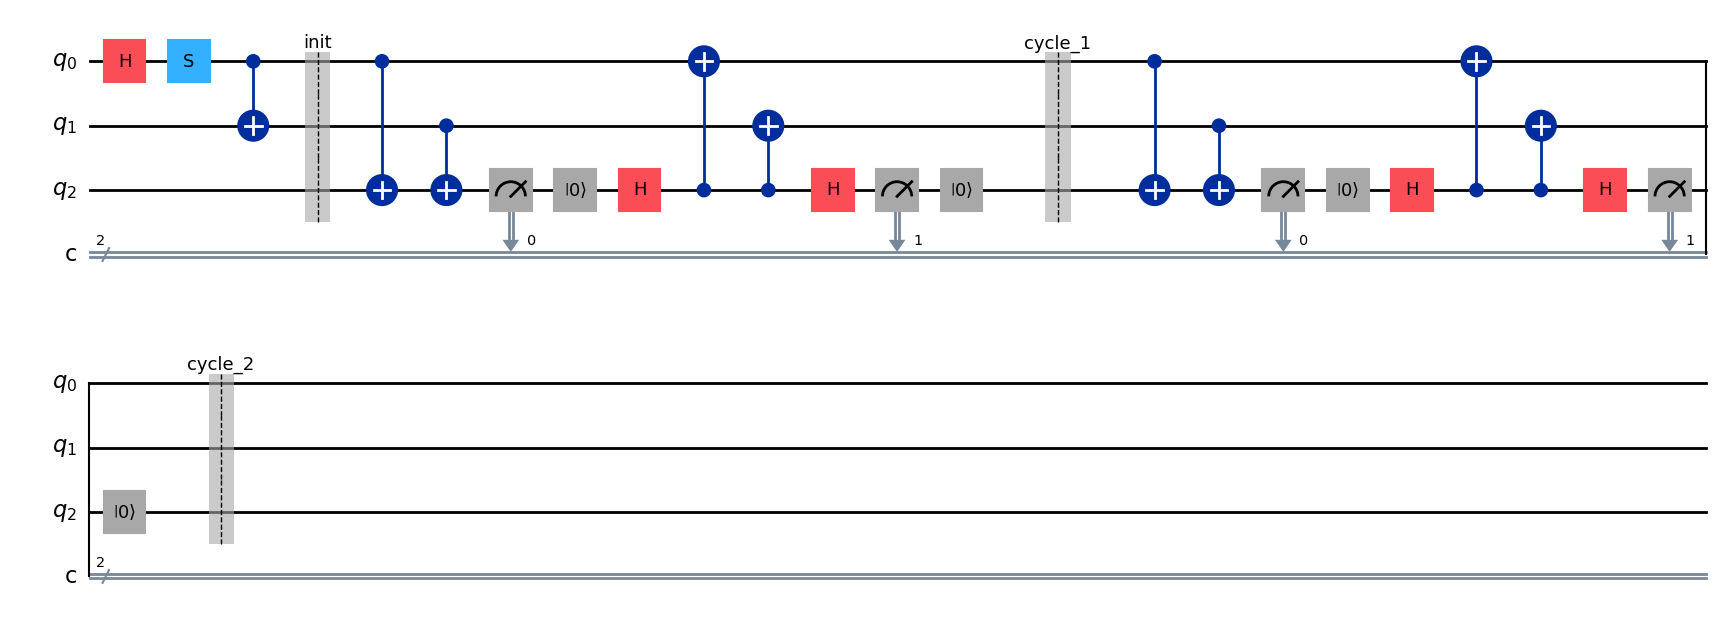

In [56]:
qc.draw('mpl')
